In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.special import gammaln
from scipy.special import gamma

In [2]:
def AON(p,N):
    G=nx.Graph()
    G.add_edge(1,2)
    t=2    
    while G.number_of_nodes() < N:       
        target=random.choice(list(G.nodes()))
        neighbours=list(G.neighbors(target))
        G.add_edge(t+1,target)
        if random.random() < p:
            edges=[(t+1,nb) for nb in neighbours]
            G.add_edges_from(edges)
        t=t+1
    numedges=G.number_of_edges()
    return (G,numedges)

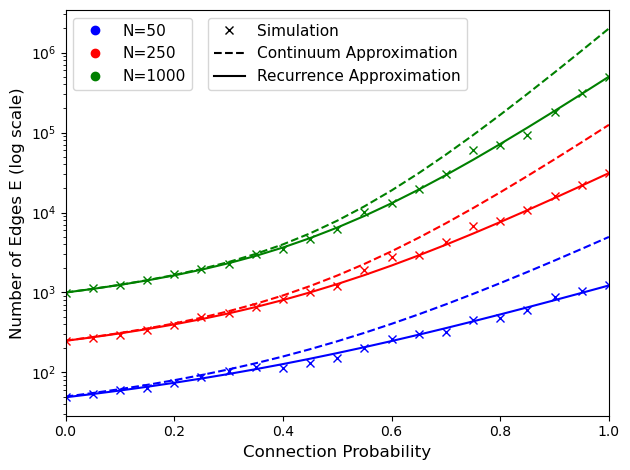

In [3]:
p_values=np.linspace(0,1,21)
N_values=[50,250,1000]
trials=10
colors=['blue','red','green']
color_legend=[]
for index,N in enumerate(N_values):
    edges=[]
    expected_edges=[]
    expected_edges2=[]
    for p in p_values:
        trial_edges=[]
        for i in range(trials):
            (G,AON_edges)=AON(p,N)
            trial_edges.append(AON_edges)
        edges.append(np.mean(trial_edges))
        if np.isclose(p,0.5):
            expected_AON_edges=(N)*(np.log(N)+1)
            expected_AON_edges2=N*np.sum(1/np.arange(2,N+1))
        else:
            expected_AON_edges=(1/(1-2*p))*((N)-2*p*(N)**(2*p))
            expected_AON_edges2=(1/(1-2*p))*(N-np.exp(gammaln(N+2*p)-gammaln(N)-gammaln(1+2*p)))
        expected_edges.append(expected_AON_edges)
        expected_edges2.append(expected_AON_edges2)
    c=colors[index]
    plt.plot(p_values,edges,color=c,marker='x',linestyle='none')
    plt.plot(p_values,expected_edges,color=c,linestyle='--')
    plt.plot(p_values,expected_edges2,color=c)
    color_legend.append(plt.Line2D([], [], color=c, marker='o', linestyle='none', label=f'N={N}'))  
plt.xlim([0,1])
plt.xlabel('Connection Probability',fontsize=12)
plt.ylabel('Number of Edges E (log scale)',fontsize=12)
plt.yscale('log')
style_legend = [
    plt.Line2D([], [], color='k', marker='x', linestyle='none', label='Simulation'),
    plt.Line2D([], [], color='k', linestyle='--', label='Continuum Approximation'),
    plt.Line2D([], [], color='k', linestyle='-', label='Recurrence Approximation')
]
first_legend = plt.legend(handles=color_legend,loc='upper left',prop={'size': 11})
plt.gca().add_artist(first_legend) 
plt.legend(handles=style_legend, loc='upper center',prop={'size': 11})
plt.tight_layout()
plt.show()

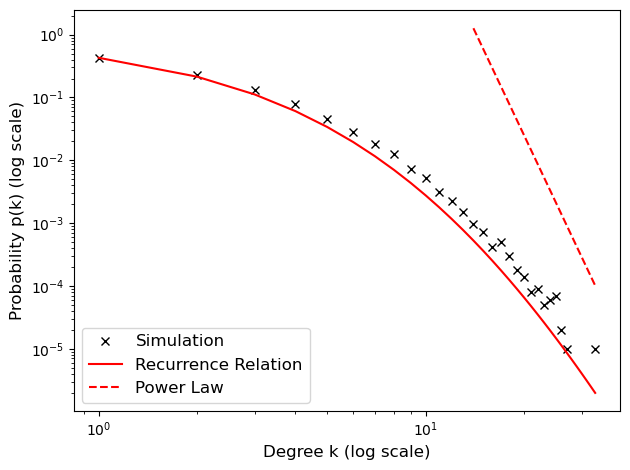

In [4]:
N=10000
p=0.1
trials=10
all_counts=[]
max_degree=0
for i in range(trials):
    G,_ = AON(p,N)
    degrees=[d for n,d in G.degree()]
    counts=np.bincount(degrees)
    all_counts.append(counts)
    if max(degrees)>max_degree:
        max_degree=max(degrees)
sum_counts=np.zeros(max_degree+1)
for counts in all_counts:
    sum_counts[:len(counts)]+=counts
avg_counts=sum_counts/trials 
pk=avg_counts[1:]/N
k=np.array(range(1,max_degree+1))
nonzero=pk>0
k_new=k[nonzero]
pk_new=pk[nonzero]   
nk=np.zeros(max_degree)
nk[0]=(1-p)/(2+p)
for j in range(2,max_degree+1):
    nk[j-1]=nk[j-2]*(1+p*(j-1))/(2+p*(j))    
klarge=1000
nlarge=(1-p)/(2+p)
for l in range(2,klarge+1):
    nlarge=nlarge*(1+p*(l-1))/(2+p*(l))
C=nlarge*(klarge**((1+p)/p))
powerlaw=C*(k**(-(1+p)/p))
plt.loglog(k_new,pk_new,color='black',marker='x',linestyle='none',label='Simulation')
plt.loglog(k,nk,color='red',linestyle='-',label='Recurrence Relation')
plt.loglog(k[-20:],powerlaw[-20:],'r--',label='Power Law')
plt.xlabel('Degree k (log scale)',fontsize='12')
plt.ylabel('Probability p(k) (log scale)',fontsize='12')
plt.legend(loc='lower left',prop={'size': 12})
plt.tight_layout()
plt.show()

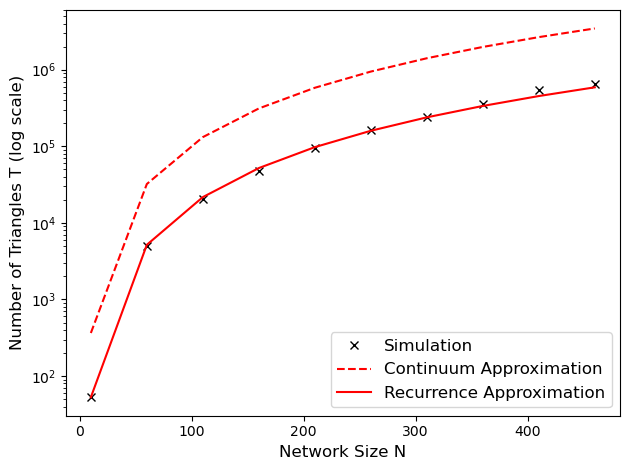

In [5]:
p=0.75
maxN=500
N_values=np.arange(10,maxN,50)
trials=50
tri_mean=[]
exptri1=[]
exptri2=[] 
Tvalues=np.zeros(maxN)
if p == 0.5:
    ksum=0
    for i in range(2,maxN):
        Ni=i+1
        ksum=ksum+1/(Ni-1)
        Tvalues[i]=Tvalues[i-1]*(Ni+0.5)/(Ni-1)+(ksum)         
else:
    f=1+2*p #setting equal to f(2)
    for i in range(2,maxN):
        Ni=i+1
        Tvalues[i]=Tvalues[i-1]*((Ni-1+3*p)/(Ni-1))+2*p/((Ni-1)*(1-2*p))*(Ni-1-f)
        f=f*((Ni-1+2*p)/(Ni-1)) 
for N in N_values:
    t=N-1
    tri=[]
    for i in range(trials):
        G,_=AON(p,N)
        tri.append(sum(nx.triangles(G).values())/3)
    tri_mean.append(np.mean(tri))
    exptri2.append(Tvalues[t])
    if p == 0.5:
        exptri1.append(-2*(t)*np.log(t)-6*t+6*(t**(1.5)))       
    elif np.isclose(p,1/3):
        exptri1.append(2*t*(np.log(t)-2)+4*(t*(2/3)))                   
    else:
        exptri1.append(2*p/(1-2*p)*((1/(1-3*p))*t+2*(t**(2*p)))-(6*p/(1-3*p))*(t**(3*p)))

plt.plot(N_values,tri_mean,color='black',marker='x',linestyle='none',label='Simulation')
plt.plot(N_values,exptri1,'r--',label='Continuum Approximation')
plt.plot(N_values,exptri2,'r-',label='Recurrence Approximation')
plt.xlabel('Network Size N',fontsize='12')
plt.ylabel('Number of Triangles T (log scale)',fontsize='12')
plt.yscale('log')
plt.legend(loc='lower right',prop={'size':12})
plt.tight_layout()
plt.show()    

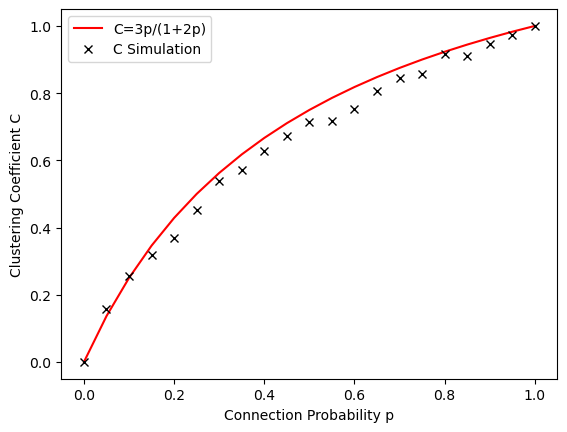

In [6]:
N=100
pvalues=np.linspace(0,1,21)
trials=10
C=[]
Csim_mean=[]
for p in pvalues:  
    C.append(3*p/(1+2*p))
    Csim=[]
    for i in range(trials):
        G,_=AON(p,N)
        Csim.append(nx.transitivity(G))
    Csim_mean.append(np.mean(Csim))   
plt.plot(pvalues,C,'r-',label='C=3p/(1+2p)')
plt.plot(pvalues,Csim_mean,color='black',marker='x',linestyle='none',label='C Simulation')
plt.xlabel('Connection Probability p')
plt.ylabel('Clustering Coefficient C')
plt.legend()
plt.show()

In [7]:
def r_recurrence(p,N):
    E,T,R,S1,S2=0,0,0,1,2
    for n in range(3,N+1):
        Eold,Told,Rold,S1old,S2old=E,T,R,S1,S2
        E=Eold*(1 + 2*p/(n-1) ) + 1
        T=Told*(1 + 3*p/(n-1) ) + Eold*( (2*p)/(n-1) )
        R=Rold*(1 + 3*p/(n-1) ) + Eold*( (2+4*p)/(n-1) )
        S1=S1old*(1 + 4*p/(n-1)) + Told*( 3*p/(n-1) ) + Rold*( (2+6*p)/(n-1) ) + Eold*( (4+12*p)/(n-1) ) + 1
        S2=S2old*(1 + 4*p/(n-1)) + Rold*( (6+12*p)/(n-1) )+  Eold*( (12+20*p)/(n-1) ) + 2
    return ((2*E*S1-2*(R+E)**2)/(E*S2-2*(R+E)**2))

def r_continuum(p,N):
    if p ==0:
        E=N-1
        R=2*N-2
        S1=9*N-4*np.log(N)-8
        S2=26*N-12*np.log(N)-24
    elif np.isclose(p,0.25):
        E=(1/(1-2*p))*((N)-2*p*(N)**(2*p))
        R=((2+4*p)/(1-2*p))*(1/(1-3*p)*N+2*N**(2*p))-((6+12*p)/(1-3*p))*N**(3*p)
        S2=-1112*N+1296*N**(3/4)-182*N**(1/2)+252*N*np.log(N)
        S1=-449*N+522*N**(3/4)-73*N**(1/2)+102*N*np.log(N)
    elif np.isclose(p,1/3):
        E=(1/(1-2*p))*((N)-2*p*(N)**(2*p))
        R=10*(N*(np.log(N)-2)+2*N**(2/3))
        S2=720*N*(4/3)-474*N-244*N**(2/3)-300*N*np.log(N)
        S1=304*N*(4/3)-201*N-102*N**(2/3)-126*N*np.log(N)
    elif np.isclose(p,0.5):
        E=N*(np.log(N)+1)
        R=8*N*(3*N**(1/2)-3-np.log(N))
        S2=240*N**2-576*N**(3/2)+338*N+74*N*np.log(N)
        S1=108*N**2-258*N**(3/2)+151*N+33*N*np.log(N)
    else:
        E=(1/(1-2*p))*((N)-2*p*(N)**(2*p))
        R=((2+4*p)/(1-2*p))*(1/(1-3*p)*N+2*N**(2*p))-((6+12*p)/(1-3*p))*N**(3*p)
        d1=(15*p+9)/((1-2*p)*(1-3*p)*(1-4*p))
        d2=(36*p**2+32*p+8)/((1-2*p)*(-2*p))
        d3=-(90*p**2+60*p+12)/((1-3*p)*(-p))
        d4=1-(d1+d2+d3)  
        S1=d1*N+d2*N**(2*p)+d3*N**(3*p)+d4*N**(4*p)
        c1=(22*p+26)/((1-2*p)*(1-3*p)*(1-4*p))
        c2=(56*p**2+72*p+24)/((1-2*p)*(-2*p))
        c3=-(36*(1+2*p)**2)/((1-3*p)*(-p))
        c4=2-(c1+c2+c3)
        S2=c1*N+c2*N**(2*p)+c3*N**(3*p)+c4*N**(4*p)    
    return ((2*E*S1-2*(R+E)**2)/(E*S2-2*(R+E)**2))    
    
def r_plot(trials,numprobs,N):
    pvalues=np.linspace(0,1,numprobs)
    rsimmean=[]
    rrec=[]
    rcont=[]
    for p in pvalues:
        if p==1:
            rsimmean.append(1)
            rrec.append(1)
            rcont.append(1)
        else:
            rsim=[]
            for i in range(trials):
                G,_=AON(p,N)
                rsim.append(nx.degree_pearson_correlation_coefficient(G))
            rsimmean.append(np.mean(rsim))
            rrec.append(r_recurrence(p,N))
            rcont.append(r_continuum(p,N))          
    plt.figure(figsize=(10, 6))
    plt.plot(pvalues,rsimmean,color='black',marker='x',linestyle='--',label='Simulation')
    plt.plot(pvalues,rrec,'r-',label='Recurrence Approximation')
    plt.plot(pvalues,rcont,'r--',label='Continuum Approximation')
    plt.xlabel('Connection Probability p',fontsize=12)
    plt.ylabel('Pearson Correlation Coefficient r',fontsize=12)
    plt.legend(loc='lower right',prop={'size':12})
    plt.tight_layout()
    plt.show()

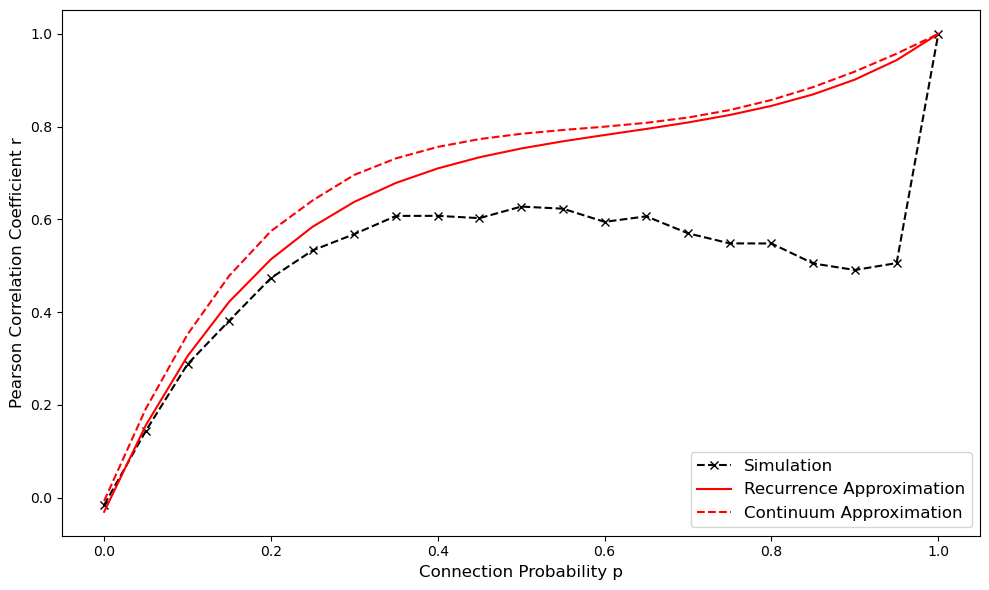

In [8]:
r_plot(100,21,1000)

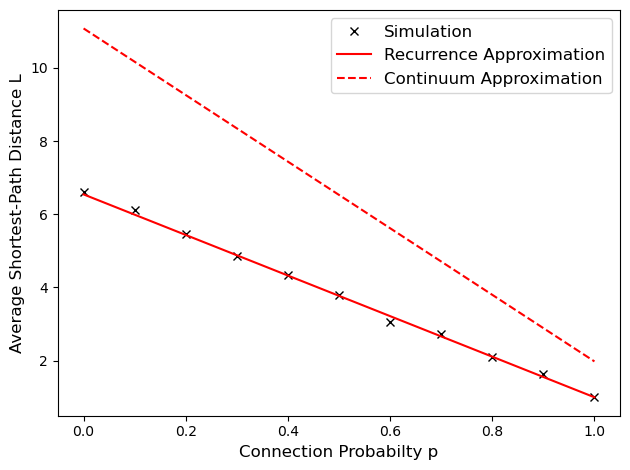

In [9]:
def S_reccurence(p,N):
    if N<=1:
        return 0
    S=1
    for i in range(3,N+1):
        S=((i+1)/(i-1))*S+1+(i-2)*(1-p)
    return ((2/(N*(N-1)))*S)
N=100
trials=10
pvalues=np.linspace(0,1,11)
Lsim_mean=[]
Lcont=[]
Lrec=[]
for p in pvalues: 
    Lsim=[]
    for _ in range(trials):
        G,_=AON(p,N)
        Lsim.append(nx.average_shortest_path_length(G))
    Lsim_mean.append(np.mean(Lsim))
    Lrec.append(S_reccurence(p,N))
    Lcont.append((2/(N*(N-1)))*((1-p)*((N-1)**2)*np.log(N-1)+(N-1)**2))
plt.plot(pvalues,Lsim_mean,color='black',marker='x',linestyle='none',label='Simulation')
plt.plot(pvalues,Lrec,'r-',label='Recurrence Approximation')
plt.plot(pvalues,Lcont,'r--',label='Continuum Approximation')
plt.xlabel('Connection Probabilty p',fontsize=12)
plt.ylabel('Average Shortest-Path Distance L',fontsize=12)
plt.legend(loc='upper right',prop={'size':12})
plt.tight_layout()
plt.show()